# FGSM Attack on Resnet-50 model fine-tuned on MNIST Dataset

In [22]:
import torch, torchvision
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.transforms import ToTensor, Compose, Normalize, Grayscale
import torch.optim as optim
import torch.nn as nn
import sklearn.metrics
import matplotlib.pyplot as plt
from art.estimators.classification import PyTorchClassifier
import numpy as np
from matplotlib.gridspec import GridSpec


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)

mps


### Load MNIST Dataset and Fine-tuned ResNet50 model

In [9]:
# --- load checkpoint dict ---
ckpt = torch.load("resnet50_mnist.pt", weights_only=True)
num_classes = ckpt["num_classes"]
mean, std   = ckpt["normalize_mean"], ckpt["normalize_std"]

# --- rebuild architecture (MUST match how it was trained) ---
model = resnet50(weights=None)                      # arch only, no ImageNet download
model.fc = nn.Linear(model.fc.in_features, num_classes)   # same single-Linear head
model.load_state_dict(ckpt["state_dict"])
model = model.to(device).eval()                     # eval() — freezes BN stats for the attack

print(f"Loaded fine-tuned model: {num_classes} classes")

transform = Compose([
    Grayscale(num_output_channels=3),
    ToTensor(),                                 # -> [0,1], NO Normalize here anymore
])
mnist_test  = torchvision.datasets.MNIST(root="./mnist", train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=256, shuffle=False)

print(f"Loaded MNIST test set: {len(mnist_test)} samples")


print("model on:", next(model.parameters()).device)   # -> mps / cuda / cpu

Loaded fine-tuned model: 10 classes
Loaded MNIST test set: 10000 samples
model on: mps:0


In [10]:
class NormalizedModel(nn.Module):
    def __init__(self, model, mean, std):
        super().__init__()
        self.model = model
        # buffers (not parameters): move with .to(device), never trained, saved with state
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):                       # x expected in [0, 1]
        return self.model((x - self.mean) / self.std)

wrapped = NormalizedModel(model, mean, std).to(device).eval()

# quick clean-accuracy pass — the real test that weights loaded correctly
correct = total = 0 
wrapped.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = wrapped(images.to(device)).argmax(1).cpu()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
print(f"clean accuracy: {correct/total:.4f}  ({correct}/{total})")

clean accuracy: 0.9649  (9649/10000)


### Enable FGSM Attack

- Wrap PyTorch model using PyTorchClassifier
- ART needs loss function + optimizer
- This enables adversarial attacks

In [13]:
# ART targets CPU/CUDA — it has no MPS path, so run the attack on CPU (Mac).
art_device = "gpu" if torch.cuda.is_available() else "cpu"
wrapped = wrapped.to("cuda" if torch.cuda.is_available() else "cpu").eval()

classifier = PyTorchClassifier(
    model=wrapped,
    loss=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(wrapped.parameters(), lr=0.001),
    input_shape=(3, 28, 28),
    nb_classes=num_classes,
    clip_values=(0.0, 1.0),                                # inputs are [0,1] -> eps in pixel space
    device_type=art_device
)

print("classifier ready on", art_device)

classifier ready on cpu


# Step 6 FGSM Attack

- Use FastGradientMethod
- Experiment with epsilon values
- Small epsilon → subtle perturbation
- Large epsilon → stronger attack

In [16]:
# ART works on NumPy arrays, so move data to CPU and convert to NumPy
n_samples = 1000                         # subset — CPU + ResNet-50 is slow on 10k
xs, ys, collected = [], [], 0 
for images, labels in test_loader:       # images already [0,1], shape (B,3,28,28)
    xs.append(images.numpy())
    ys.append(labels.numpy())
    collected += images.size(0)
    if collected >= n_samples:
        break

x_test = np.concatenate(xs)[:n_samples].astype(np.float32)
y_test = np.concatenate(ys)[:n_samples]
print("x_test", x_test.shape, "range", x_test.min(), x_test.max(),  # expect ~0.0 .. 1.0
    "| y_test", y_test.shape)

x_test (1000, 3, 28, 28) range 0.0 1.0 | y_test (1000,)


In [17]:
from art.attacks.evasion import FastGradientMethod

epsilon = 8/255                          # ≈ 0.031 — a real pixel-space budget
attack  = FastGradientMethod(estimator=classifier, eps=epsilon)

x_test_adv = attack.generate(x=x_test)   # perturbed images, still clipped to [0,1]
print("adv range", x_test_adv.min(), x_test_adv.max())   # stays in [0,1]


def accuracy(x, y):
    preds = classifier.predict(x).argmax(axis=1)   # predict -> logits (N,10)
    return (preds == y).mean()

clean_acc = accuracy(x_test,     y_test)
adv_acc   = accuracy(x_test_adv, y_test)
print(f"clean accuracy      : {clean_acc:.4f}")
print(f"adversarial accuracy: {adv_acc:.4f}   (eps={epsilon:.3f})")

adv range 0.0 1.0
clean accuracy      : 0.9670
adversarial accuracy: 0.0970   (eps=0.031)


### Attack Visualization

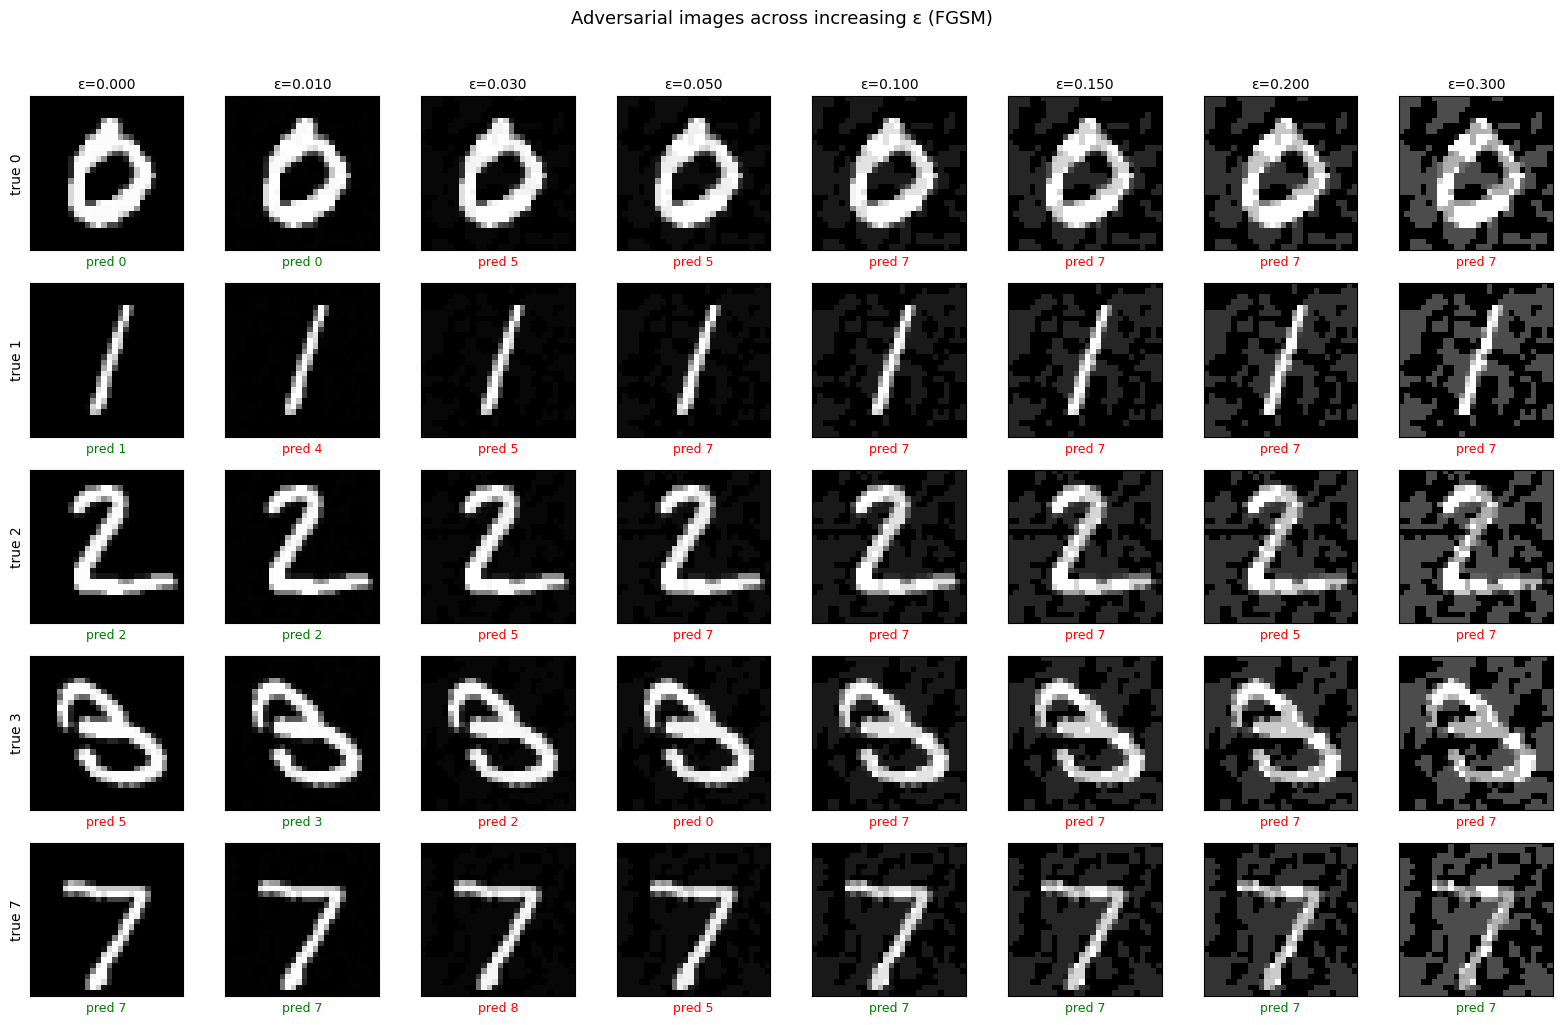

In [20]:
import numpy as np, matplotlib.pyplot as plt

epsilons    = np.array([0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30])        # 0.000, 0.0375, 0.075, ... 0.300
show_digits = [0, 1, 2, 3, 7]                 # rows: pick any subset of 0..9
sample_idxs = [int(np.where(y_test == d)[0][0]) for d in show_digits]
samples     = x_test[sample_idxs]             # (n_digits, 3, 28, 28)
true_labels = y_test[sample_idxs]

fig, axes = plt.subplots(len(show_digits), len(epsilons),
                        figsize=(2*len(epsilons), 2*len(show_digits)))

for j, eps in enumerate(epsilons):
    if eps == 0:
        adv = samples                          # ε=0 is the clean image
    else:
        adv = FastGradientMethod(estimator=classifier, eps=float(eps)).generate(x=samples)
    preds = classifier.predict(adv).argmax(axis=1)

    for i in range(len(show_digits)):
        ax = axes[i, j]
        ax.imshow(adv[i][0], cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])   # keep frame so labels render
        color = "green" if preds[i] == true_labels[i] else "red"
        ax.set_xlabel(f"pred {preds[i]}", color=color, fontsize=9)
        if j == 0:
            ax.set_ylabel(f"true {true_labels[i]}", fontsize=10)
        if i == 0:
            ax.set_title(f"ε={eps:.3f}", fontsize=10)

fig.suptitle("Adversarial images across increasing ε (FGSM)", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

eps=0.000  acc=0.9670
eps=0.010  acc=0.6430
eps=0.030  acc=0.0970
eps=0.050  acc=0.0860
eps=0.100  acc=0.0840
eps=0.150  acc=0.0840
eps=0.200  acc=0.0840
eps=0.300  acc=0.0810


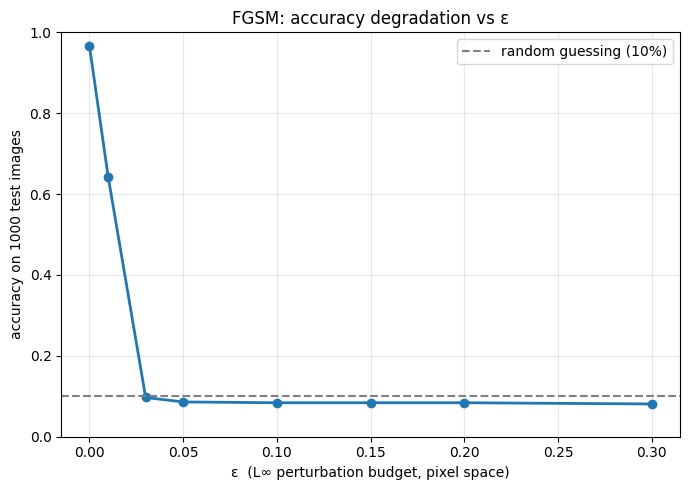

In [21]:
import numpy as np, matplotlib.pyplot as plt
from art.utils import to_categorical

# --- FGSM sign-reuse: ONE backward pass, reused across all eps ---
# sign(∂loss/∂x) is evaluated at the clean image and does NOT depend on eps,
# so a single-step L∞ FGSM at any eps is just: clip(x + eps * sign(grad)).
# This avoids re-running a full backprop (the slow part) for every eps.
y_pred = np.argmax(classifier.predict(x_test), axis=1)        # ART attacks predicted labels by default
grad   = classifier.loss_gradient(x_test, to_categorical(y_pred, num_classes))
sign   = np.sign(grad)

eps_sweep = np.array([0.00, 0.01, 0.03, 0.05, 0.10, 0.15, 0.20, 0.30])
accs = [] 
for eps in eps_sweep:
    x_adv = np.clip(x_test + eps * sign, 0.0, 1.0).astype(np.float32)   # arithmetic only, no model call
    a = accuracy(x_adv, y_test)                                         # one forward pass
    accs.append(a)  
    print(f"eps={eps:.3f}  acc={a:.4f}")

accs = np.array(accs)

# --- plot ---
plt.figure(figsize=(7, 5))
plt.plot(eps_sweep, accs, marker="o", linewidth=2)
plt.axhline(0.10, ls="--", color="gray", label="random guessing (10%)")
plt.xlabel("ε  (L∞ perturbation budget, pixel space)")
plt.ylabel(f"accuracy on {len(y_test)} test images")
plt.title("FGSM: accuracy degradation vs ε")
plt.ylim(0, 1.0); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

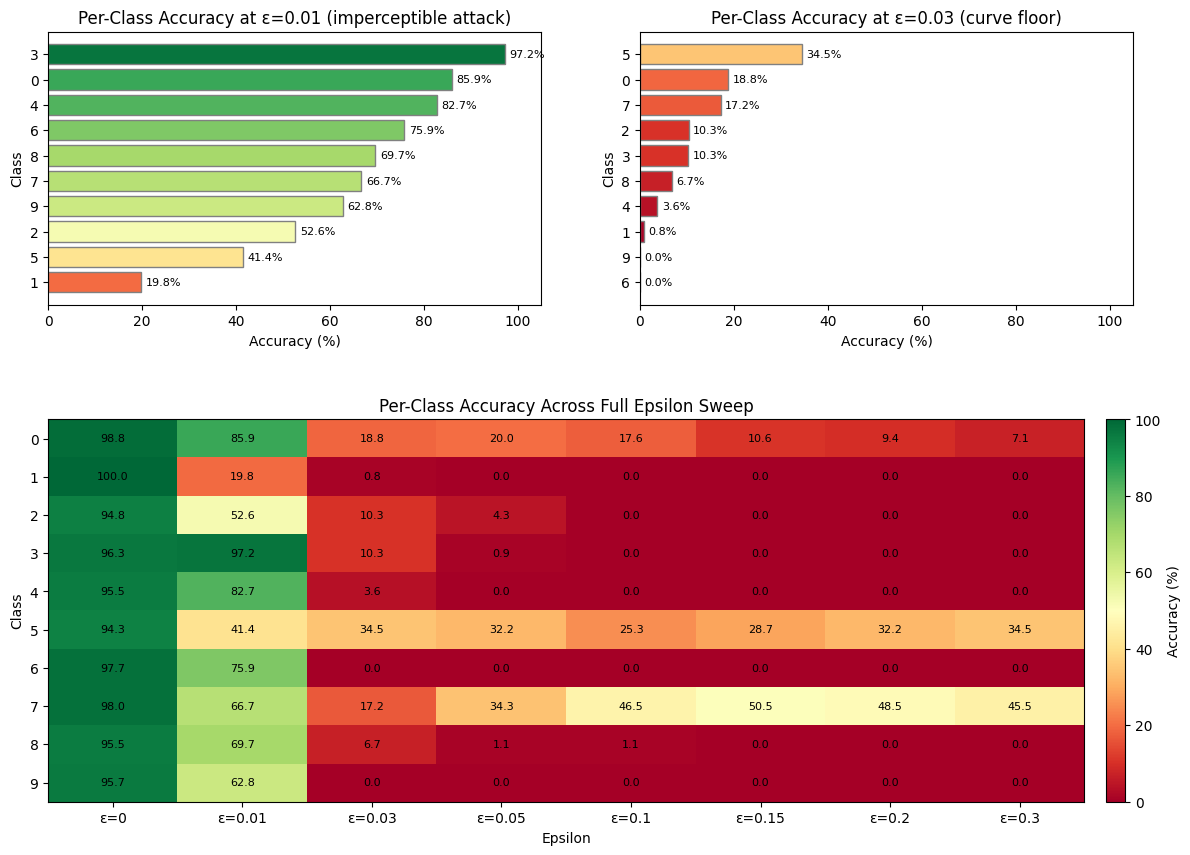

In [23]:
classes = [str(d) for d in range(num_classes)]   # MNIST digits 0..9
cmap = plt.cm.RdYlGn

# --- per-class accuracy matrix: rows = class, cols = eps (reuses sign-trick) ---
percls = np.full((num_classes, len(eps_sweep)), np.nan)
for j, eps in enumerate(eps_sweep):
    x_adv = np.clip(x_test + eps * sign, 0.0, 1.0).astype(np.float32)
    preds = classifier.predict(x_adv).argmax(axis=1)
    for c in range(num_classes):
        mask = (y_test == c)
        if mask.any():
            percls[c, j] = (preds[mask] == c).mean() * 100

def bar_at(ax, e, title):
    j = int(np.argmin(np.abs(eps_sweep - e)))
    vals  = percls[:, j]
    order = np.argsort(vals)                       # highest on top
    ax.barh([classes[i] for i in order], vals[order],
            color=cmap(vals[order] / 100), edgecolor="gray")
    for y, v in enumerate(vals[order]):
        ax.text(v + 1, y, f"{v:.1f}%", va="center", fontsize=8)
    ax.set_xlim(0, 105); ax.set_xlabel("Accuracy (%)"); ax.set_ylabel("Class"); ax.set_title(title)

fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, height_ratios=[1, 1.4], figure=fig, hspace=0.35, wspace=0.2)

bar_at(fig.add_subplot(gs[0, 0]), 0.01, "Per-Class Accuracy at ε=0.01 (imperceptible attack)")
bar_at(fig.add_subplot(gs[0, 1]), 0.03, "Per-Class Accuracy at ε=0.03 (curve floor)")

axh = fig.add_subplot(gs[1, :])
im = axh.imshow(percls, cmap=cmap, vmin=0, vmax=100, aspect="auto")
axh.set_xticks(range(len(eps_sweep)), [f"ε={e:g}" for e in eps_sweep])
axh.set_yticks(range(num_classes), classes)
axh.set_xlabel("Epsilon"); axh.set_ylabel("Class")
axh.set_title("Per-Class Accuracy Across Full Epsilon Sweep")
for i in range(num_classes):  
    for j in range(len(eps_sweep)):
        axh.text(j, i, f"{percls[i, j]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axh, fraction=0.025, pad=0.02).set_label("Accuracy (%)")

plt.show()

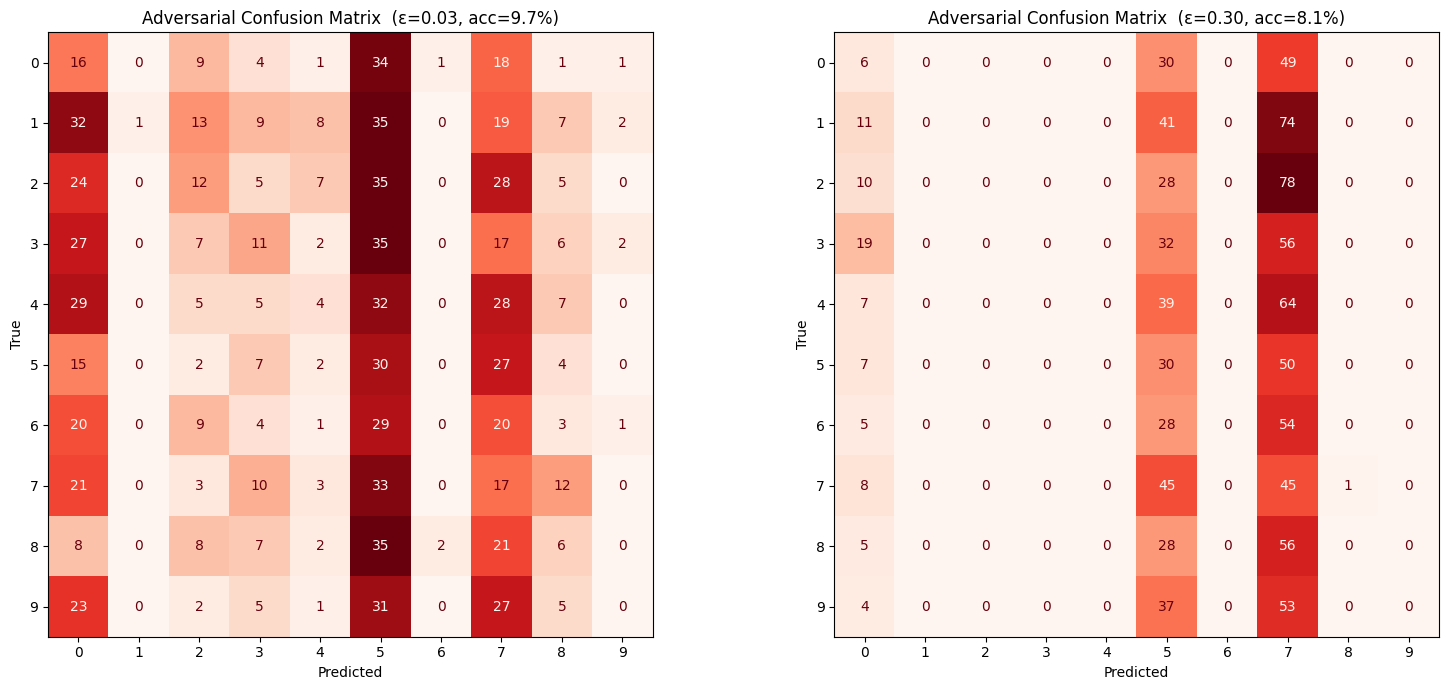

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np, matplotlib.pyplot as plt

def preds_at(eps):
    x_adv = np.clip(x_test + eps * sign, 0.0, 1.0).astype(np.float32)   # sign-reuse
    return classifier.predict(x_adv).argmax(axis=1)

eps_show = [0.03, 0.30]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, eps in zip(axes, eps_show):
    preds = preds_at(eps)
    acc   = (preds == y_test).mean()
    cm    = confusion_matrix(y_test, preds, labels=range(num_classes))
    ConfusionMatrixDisplay(cm, display_labels=range(num_classes)).plot(
        ax=ax, cmap="Reds", colorbar=False, values_format="d"
    )
    ax.set_title(f"Adversarial Confusion Matrix  (ε={eps:.2f}, acc={acc:.1%})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.tight_layout()
plt.show()

eps=0.00  correct=0.990  incorrect=0.803  gap=+0.187
eps=0.01  correct=0.903  incorrect=0.745  gap=+0.158
eps=0.03  correct=0.741  incorrect=0.739  gap=+0.002
eps=0.05  correct=0.893  incorrect=0.922  gap=-0.028
eps=0.10  correct=0.967  incorrect=0.980  gap=-0.012
eps=0.15  correct=0.986  incorrect=0.983  gap=+0.003
eps=0.20  correct=0.989  incorrect=0.991  gap=-0.003
eps=0.30  correct=0.998  incorrect=0.994  gap=+0.004


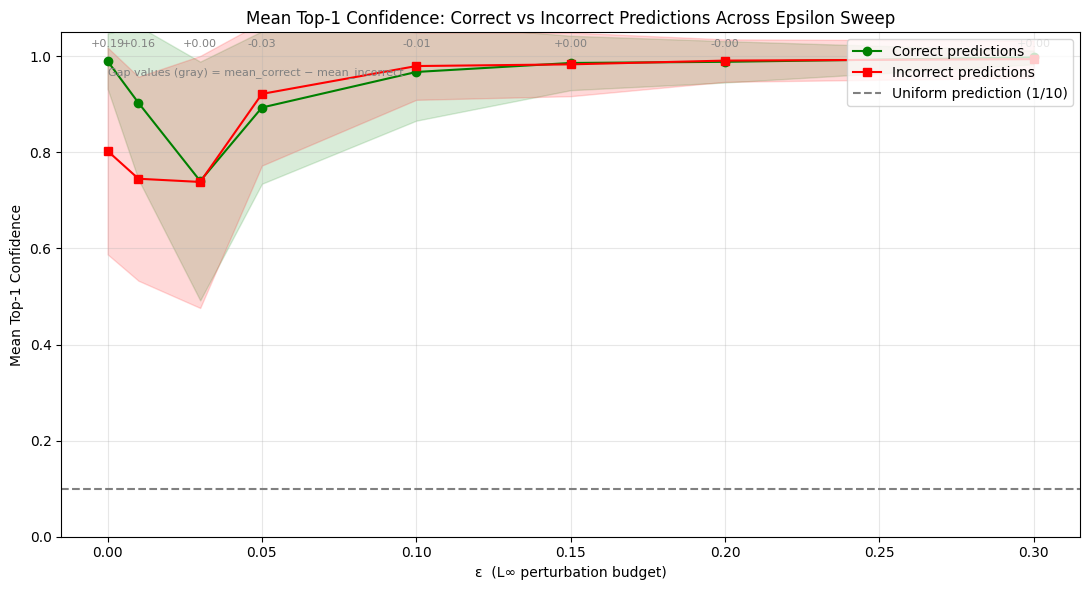

In [25]:
def softmax(z):                                   # logits -> probabilities
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

mean_c, std_c, mean_w, std_w, gaps = [], [], [], [], []
for eps in eps_sweep:
    x_adv  = np.clip(x_test + eps * sign, 0.0, 1.0).astype(np.float32)
    probs  = softmax(classifier.predict(x_adv))   # (N, 10)
    conf   = probs.max(axis=1)                     # top-1 confidence per sample
    preds  = probs.argmax(axis=1)
    correct = preds == y_test

    mc = conf[correct].mean()  if correct.any()    else np.nan
    mw = conf[~correct].mean() if (~correct).any() else np.nan
    mean_c.append(mc); std_c.append(conf[correct].std()  if correct.any()    else np.nan)
    mean_w.append(mw); std_w.append(conf[~correct].std() if (~correct).any() else np.nan)
    gaps.append(mc - mw)
    print(f"eps={eps:.2f}  correct={mc:.3f}  incorrect={mw:.3f}  gap={mc-mw:+.3f}")

mean_c, std_c = np.array(mean_c), np.array(std_c)
mean_w, std_w = np.array(mean_w), np.array(std_w)

plt.figure(figsize=(11, 6))
plt.plot(eps_sweep, mean_c, "o-", color="green", label="Correct predictions")
plt.fill_between(eps_sweep, mean_c-std_c, mean_c+std_c, color="green", alpha=0.15)
plt.plot(eps_sweep, mean_w, "s-", color="red", label="Incorrect predictions")
plt.fill_between(eps_sweep, mean_w-std_w, mean_w+std_w, color="red", alpha=0.15)
plt.axhline(1/num_classes, ls="--", color="gray", label=f"Uniform prediction (1/{num_classes})")
for e, mc, mw in zip(eps_sweep, mean_c, mean_w):
    if not (np.isnan(mc) or np.isnan(mw)):
        plt.text(e, 1.02, f"{mc-mw:+.2f}", ha="center", fontsize=8, color="gray")
plt.text(0.0, 0.96, "Gap values (gray) = mean_correct − mean_incorrect", fontsize=8, color="gray")
plt.ylim(0, 1.05); plt.xlabel("ε  (L∞ perturbation budget)"); plt.ylabel("Mean Top-1 Confidence")
plt.title("Mean Top-1 Confidence: Correct vs Incorrect Predictions Across Epsilon Sweep")
plt.legend(loc="upper right"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()